In [2]:
import numpy as np    # Is used to import the Numpy library with a short name (np) for fast and easy mathematical operations.


import pandas as pd   # Means importing the pandas library with the short name (pd) for easy dada analysis and table handling.


import matplotlib.pyplot as plt  # It used to importing the pyplot module of matplotlib with the short name (plt) to create graphs and charts easily.


import seaborn as sns # Is used to importing the seabron library with the short name (sns) for advanced and beautiful data visualization.


import warnings
warnings.simplefilter("ignore")  # This code imports the warnings modules and hides warnings messages using ("ignore")

# 📂 Data Loading in Python

In [3]:
df = pd.read_excel(r"C:\Users\Nilesh Awagan\OneDrive\Desktop\Python_project\project Data new (1).xlsx")

# print Data Successfully Imported!

# 📊 Basic EDA Started...

In [4]:
df.shape

(11251, 15)

In [5]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [7]:
df.isnull().sum()

User_ID                 0
Cust_name               0
Product_ID              0
Gender                  0
Age Group               0
Age                     0
Marital_Status          0
State                   0
Zone                    0
Occupation              0
Product_Category        0
Orders                  0
Amount                 12
Status              11251
unnamed1            11251
dtype: int64

In [8]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount', 'Status', 'unnamed1'],
      dtype='object')

# 🧹 Data Cleaning Started...

🗑️ Dropped two unnecessary columns from the dataset

In [9]:
df.drop(['Status', 'unnamed1'],axis=1,inplace=True)

df.head(3)

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0


🧹 Removed columns containing missing values using dropna()

In [10]:
df.dropna(inplace=True)

df.isnull().sum()

User_ID             0
Cust_name           0
Product_ID          0
Gender              0
Age Group           0
Age                 0
Marital_Status      0
State               0
Zone                0
Occupation          0
Product_Category    0
Orders              0
Amount              0
dtype: int64

🔄 Replaced 0 values in the Marital_Status column with "Single" using string replacement.

In [11]:
df["Marital_Status"] = df["Marital_Status"].astype(str).str.replace("0","Single")

🔄 Replaced 1 values in the Marital_Status column with "Married" using string replacement.

In [12]:
df["Marital_Status"] = df["Marital_Status"].astype(str).str.replace("1","Married")

In [13]:
df["Marital_Status"].unique()

array(['Single', 'Married'], dtype=object)

🔄 Renamed the Occupation column to Sector using rename().

In [14]:
df.rename(columns={'Occupation':'Sector'},inplace=True)

📊 Checking Final Data Structure...[.head()]


In [15]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Sector,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,Single,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,Married,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,Married,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,Single,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,Married,Gujarat,Western,Food Processing,Auto,2,23877.0


# 📊 Data Visualization Started...

🔍 Exploring Relationships Between Variables


📊 Created a Seaborn countplot to visualize order counts based on Marital_Status with different Age Group categories using hue.

🎨 Added bold bar labels, customized title styling, and removed axis labels for a cleaner visualization.

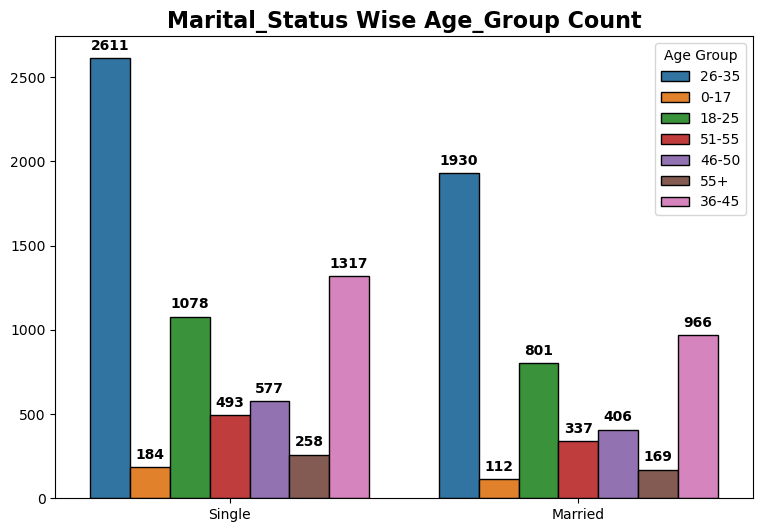

In [16]:
plt.figure(figsize=(9,6))

CT_1 = sns.countplot(x="Marital_Status",data=df,hue="Age Group",edgecolor="black")

for Q in CT_1.containers:
    CT_1.bar_label(Q,fontweight="bold",padding=4,)
    

plt.title("Marital_Status Wise Age_Group Count",color="black",fontweight="bold",fontsize=16)


plt.xlabel("")

plt.ylabel("")

plt.show()

✅ Print Final Countplot Chart Generated Successfully!

In [17]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Sector,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,Single,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,Married,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,Married,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,Single,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,Married,Gujarat,Western,Food Processing,Auto,2,23877.0


📈 This lineplot shows the Top 15 sectors with the highest orders using a red trend line and bold numeric values for better visualization.

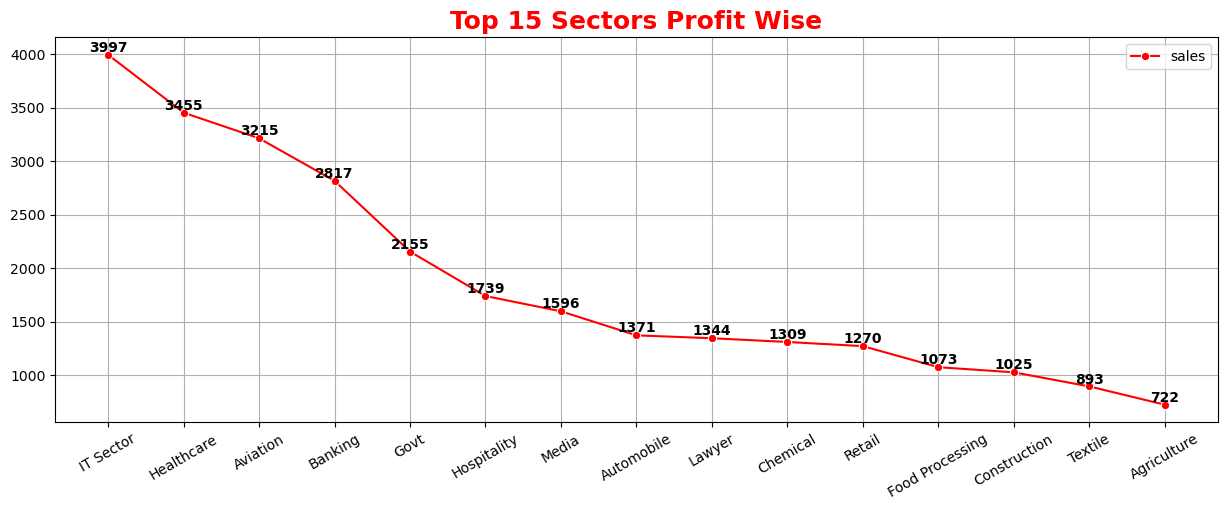

In [18]:
CT_2 = df.groupby("Sector",as_index=False)["Orders"].sum().sort_values(by="Orders",ascending=False).head(15)

CT_2

plt.figure(figsize=(15,5))

CT_A = sns.lineplot(x="Sector",y="Orders",data=CT_2,marker="o",color="r",label="sales")

for x, y in zip(CT_2["Sector"], CT_2["Orders"]):
    plt.text(x,y,str(y),ha="center",va="bottom",color="black",fontsize="10",fontweight="bold")

plt.title("Top 15 Sectors Profit Wise",color="r",fontweight="bold",fontsize="18")

plt.xticks(rotation=30)

plt.xlabel("")

plt.ylabel("")

plt.grid()

plt.show()


✅ Print Final Lineplot Chart Generated Successfully!

In [19]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Sector,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,Single,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,Married,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,Married,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,Single,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,Married,Gujarat,Western,Food Processing,Auto,2,23877.0


📊 This pie chart shows the percentage-wise amount distribution across different age groups.

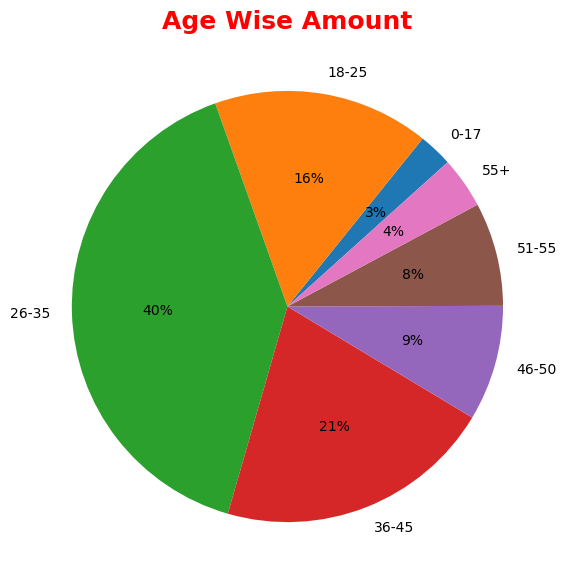

In [20]:
Pie = df.groupby('Age Group',as_index=False)['Amount'].sum()

plt.figure(figsize=(9,7))

plt.pie(Pie['Amount'],labels=Pie['Age Group'],autopct="%1.f%%",startangle=42)

plt.title("Age Wise Amount",color="r",fontweight="bold",fontsize="18")

plt.show()

✅ Print Final pie Chart Generated Successfully!

In [21]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Sector,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,Single,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,Married,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,Married,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,Single,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,Married,Gujarat,Western,Food Processing,Auto,2,23877.0


📊 This chart shows the Top 10 states with the highest 💰 sales amount and 🛒 total orders in the dataset.

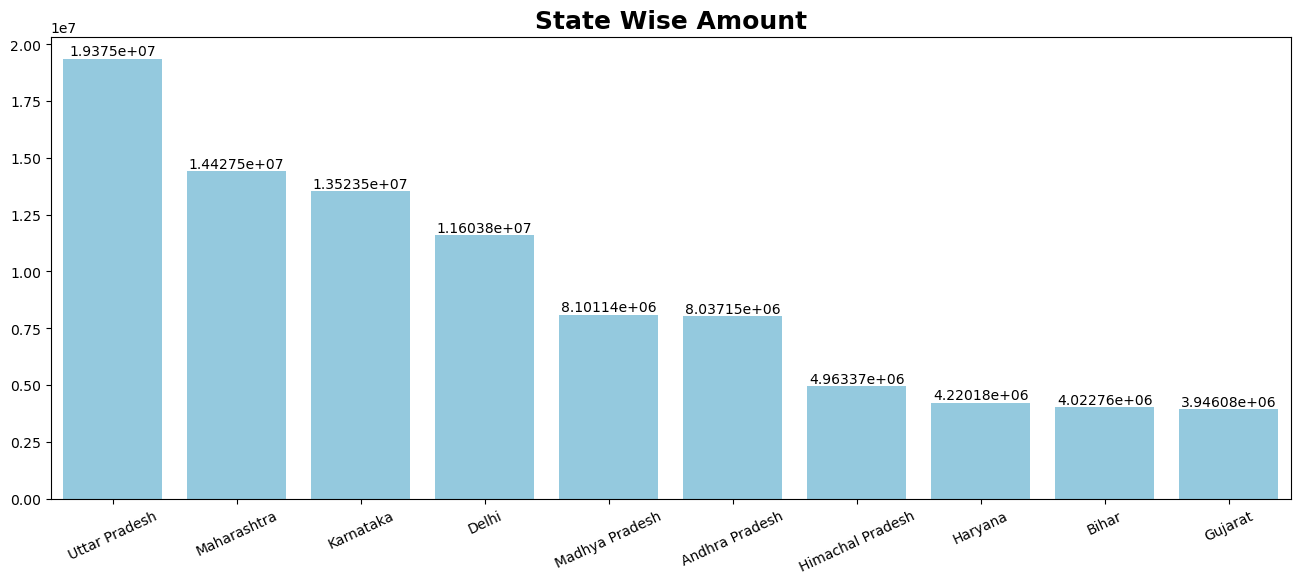

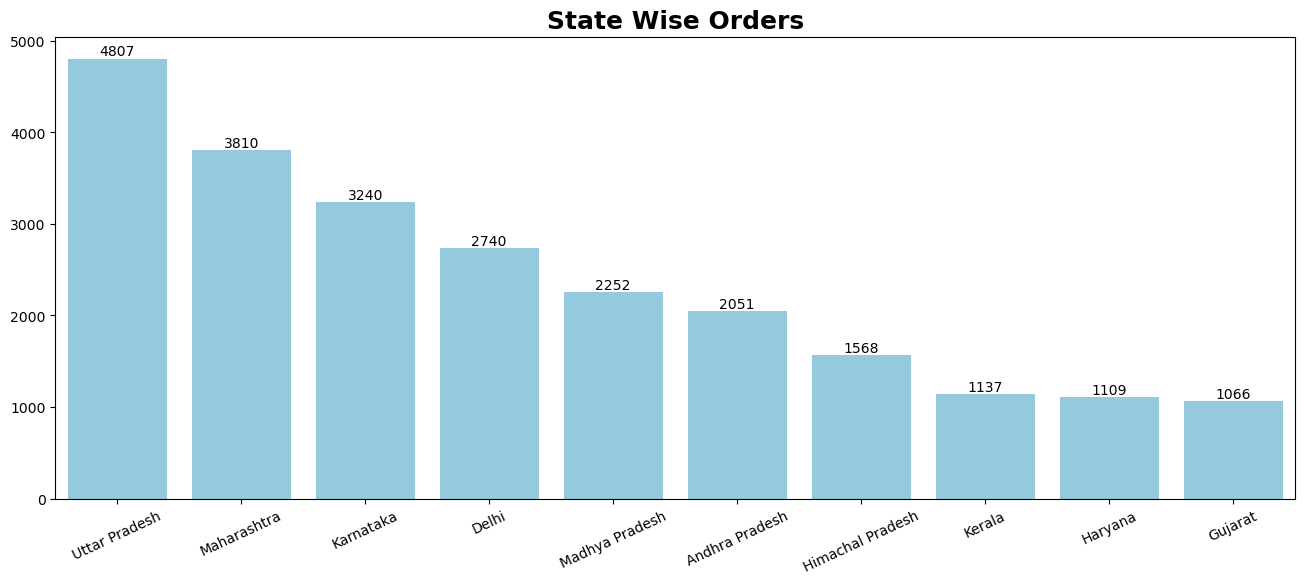

In [22]:
# State Wise Amount

A_1 = df.groupby("State",as_index=False)["Amount"].sum().sort_values(by="Amount",ascending=False).head(10)

A_1

plt.figure(figsize=(16,6))

B_1 = sns.barplot(x="State",y="Amount",data=A_1,color="skyblue")

for a in B_1.containers:
    B_1.bar_label(a)

plt.title("State Wise Amount",color="black",fontweight="bold",fontsize="18")

plt.xticks(rotation=25)

plt.xlabel("")

plt.ylabel("")

plt.show()


# State Wise Orders


A_2 = df.groupby("State",as_index=False)["Orders"].sum().sort_values(by="Orders",ascending=False).head(10)

A_2

plt.figure(figsize=(16,6))

Z_4 = sns.barplot(x="State",y="Orders",data=A_2,color="skyblue")

for x in Z_4.containers:
    Z_4.bar_label(x)

plt.xticks(rotation=25)

plt.title("State Wise Orders",color="black",fontweight="bold",fontsize="18")

plt.xlabel("")

plt.ylabel("")

plt.show()

✅ Print Final Amount Wise Bar Chart & Orders Wise Bar Chart Generated Successfully

In [26]:
df.to_excel("Project Clean File.xlsx",index=False)

# Extra Charts Create

In [ ]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Sector,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,Single,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,Married,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,Married,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,Single,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,Married,Gujarat,Western,Food Processing,Auto,2,23877.0


📌 This horizontal bar chart shows the top 5 product categories with the highest sales amount.

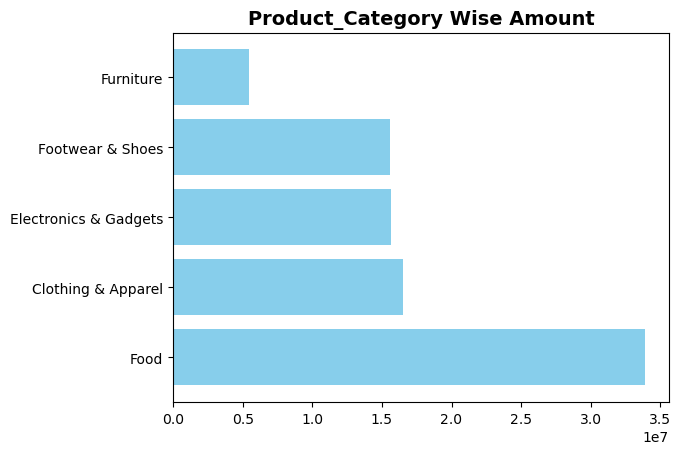

In [ ]:
barh = df.groupby("Product_Category",as_index=False)["Amount"].sum().sort_values(by="Amount",ascending=False).head(5)

barh

plt.barh(barh["Product_Category"],barh["Amount"],color="skyblue")

plt.title("Product_Category Wise Amount",color="black",fontsize=14,fontweight="bold")



plt.show()

In [ ]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Sector,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,Single,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,Married,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,Married,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,Single,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,Married,Gujarat,Western,Food Processing,Auto,2,23877.0


📌 This area chart represents the distribution of amount values across the dataset.

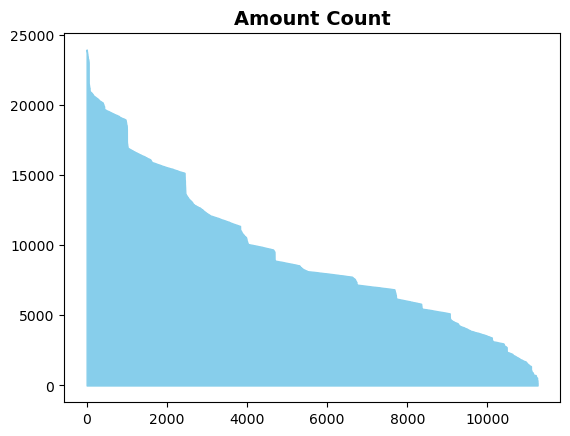

In [ ]:
plt.fill_between(df.index,df["Amount"],color="skyblue")

plt.title("Amount Count",color="black",fontweight="bold",fontsize="14")

plt.show()

In [ ]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Sector,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,Single,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,Married,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,Married,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,Single,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,Married,Gujarat,Western,Food Processing,Auto,2,23877.0


📌 This bar chart displays the top 5 product categories with the highest number of orders placed. 📦📊

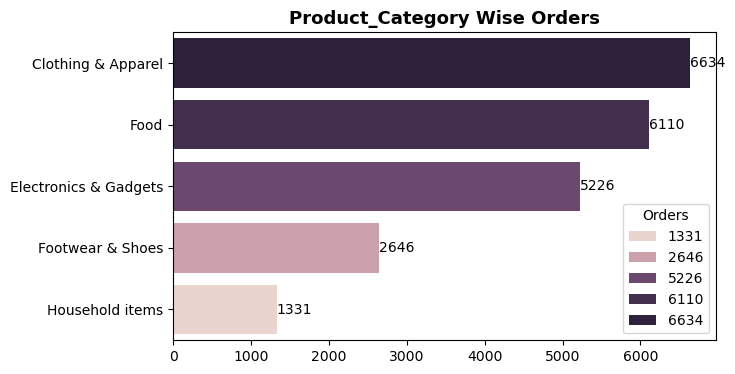

In [ ]:
O_1 = df.groupby("Product_Category",as_index=False)["Orders"].sum().sort_values(by="Orders",ascending=False).head(5)

O_1

plt.figure(figsize=(7,4))

O_2 = sns.barplot(x="Orders",y="Product_Category",data=O_1,hue="Orders")

for a in O_2.containers:
    O_2.bar_label(a)

plt.title("Product_Category Wise Orders",color="black",fontsize=13,fontweight="bold")

plt.xlabel("")

plt.ylabel("")

plt.show()



In [ ]:
df

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Sector,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,Single,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,Married,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,Married,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,Single,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,Married,Gujarat,Western,Food Processing,Auto,2,23877.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,Married,Maharashtra,Western,Chemical,Office,4,370.0
11247,1004089,Reichenbach,P00171342,M,26-35,33,Single,Haryana,Northern,Healthcare,Veterinary,3,367.0
11248,1001209,Oshin,P00201342,F,36-45,40,Single,Madhya Pradesh,Central,Textile,Office,4,213.0
11249,1004023,Noonan,P00059442,M,36-45,37,Single,Karnataka,Southern,Agriculture,Office,3,206.0
